# Refactor the mesh cut algorithm to use a meshed Surface (ref: Broken_Mesh)

In [1]:
import meshio
import numpy as np
from sympy import symbols, Eq, solve, sqrt
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D 
from ipywidgets import interact
from matplotlib.patches import Polygon
from matplotlib.collections import PolyCollection
from scipy.sparse.linalg import gmres

### Load Square Mesh
- faces (no_faces, no_points_per_face)
- coords (no_points, no_coords_per_point)

In [2]:
# LOAD MESH: [-0.5,0.5]^2, N 25 
#mesh_file_path = "/home/aspadotto/meshes/square.msh"
mesh_file_path = "square_L1_N10.msh"
mesh = meshio.read(mesh_file_path)

# face2node connectivity
faces = mesh.cells[0].data

# node coordinates
coords = mesh.points

# Add dummy columns to host faces with more than 3 vertices (put to -1)
#------> enough columns (a priori not known, say 10)
#------> therefore size of elements is 10+3=13
no_add_points = 10
no_points_per_face = no_add_points+3
faces = np.c_[faces, -1*np.ones((faces.shape[0], no_add_points))]
faces = faces.astype(int)

# Initial Sizes
Nfaces_init = faces.shape[0]
Npoints_init = coords.shape[0] #------------>important to distinguish points with double dofs 
Nfaces = Nfaces_init #--->Current sizes coincide with initial ones
Npoints = Npoints_init

# Mask for elements: 0 if uncut, 1 if cut, 2 if generated by cut
cut_faces = np.zeros(Nfaces)

# gamma_edge2face connectivity (not ordered, created during mesh breaking)

# in/ex mask (0: in, 1: ex, -1: cut cell)
side_mask = -1*np.ones(Nfaces)

# boundary mask, code:
# 0: internal
# 1: x=-0.5
# 2: y=-0.5
# 3: x= 0.5
# 4: y= 0.5
# attention: bnd_mask keeps its size after mesh breaking 
# it is ok as long as intface doesn't touch boundary
bnd_mask = np.zeros(Npoints_init)
for ino in range(Npoints_init):
    if (abs(coords[ino,0]+0.5)<1e-6):
        bnd_mask[ino]= 1  
    if (abs(coords[ino,1]+0.5)<1e-6):
        bnd_mask[ino] = 2
    if (abs(coords[ino,0]-0.5)<1e-6):
        bnd_mask[ino] = 3  
    if (abs(coords[ino,1]-0.5)<1e-6):
        bnd_mask[ino] = 4
            
# ASSUMPTIONS ON MESH
## each node has list of points in counterclock-wise sense
## first 2 points of generated element are on gamma

# other data
sigma_ex = 1
sigma_in = 1

print("Points (initial): ", Npoints, "Coords: ", coords.shape)
print ("Faces (initial): ", Nfaces)

Points (initial):  144 Coords:  (144, 3)
Faces (initial):  246


### Adapt slightly the mesh

In [3]:
rho = 0.25
N = 10 # mesh label

def move_critical_points(faces, coords, rho, N):
    for ino in range(coords.shape[0]):
        x = coords[ino,0]
        y = coords[ino,1]
        radius = np.sqrt(x**2+y**2)
        cos_theta = x/radius
        sin_theta = y/radius
        # If node is close to interface less than 1/10*mesh_size
        if (np.abs(rho-radius)<0.1*(1/N)):
            # internal nodes towards interior
            if (radius<rho):
                new_radius = radius - 0.1*(1/N)
            if (radius>rho):
                new_radius = radius + 0.1*(1/N)
            new_x = new_radius*cos_theta
            new_y = new_radius*sin_theta             
            coords[ino,0] = new_x
            coords[ino,1] = new_y
            
move_critical_points(faces, coords, rho, N)

## Create Circle Mesh



In [4]:
def create_circle_mesh(N ,rho):
    intf_edges = []
    intf_coords = []
    
    for ied in range(N): # numbering edges
        
        #create and register node (first)
        x = rho*np.cos(ied*2*np.pi/N)
        y = rho*np.sin(ied*2*np.pi/N)
        coord = np.array([x,y,0.0])
        intf_coords.append(coord)
        
        # create and register edge
        if (ied < N-1):
            edge = [ied, ied+1]
        else:
            edge = [ied, 0]
        intf_edges.append(edge)
        
    return [intf_edges, intf_coords]
                
        
No_intf_edges = 100
No_intf_points = No_intf_edges+1
rho = 0.25
[intf_edges, intf_coords] = create_circle_mesh(No_intf_edges ,rho)

### Visualize Circle Mesh

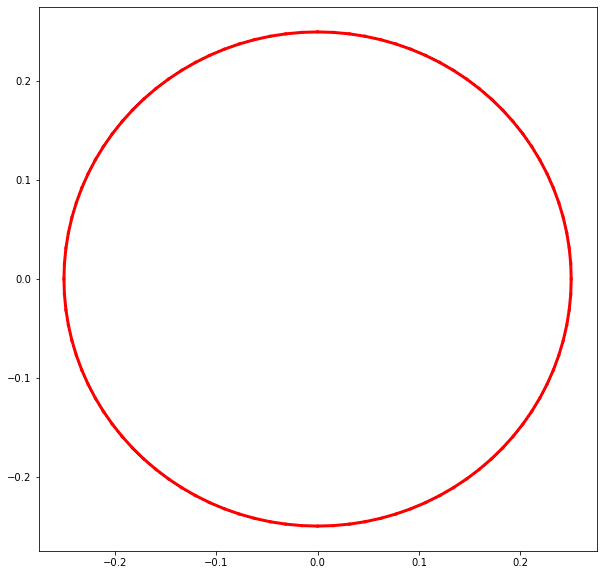

In [5]:
fig, ax = plt.subplots(figsize=(10,10))
for ied in range(No_intf_edges):
    p1 = intf_coords[intf_edges[ied][0]][:]
    p2 = intf_coords[intf_edges[ied][1]][:]
    dx = p2-p1
    xx = [p1[0],p2[0]]
    yy = [p1[1],p2[1]]
    #ax.arrow(p1[0],p1[1], dx[0],dx[1],head_width=0.005)
    ax.plot(xx,yy,'r', markersize = 4, linewidth=3)
    circle = plt.Circle((0, 0), radius=rho, edgecolor='b', facecolor='none')
    ax.add_patch(circle)

### Tools for breaking mesh
- intersection between 2 segments

In [53]:
def calc_intersection(A1, B1, A2, B2):
    def on_segment(p, q, r):
        """Check if point q lies on line segment pr"""
        if q[0] <= max(p[0], r[0]) and q[0] >= min(p[0], r[0]) and \
           q[1] <= max(p[1], r[1]) and q[1] >= min(p[1], r[1]):
            return True
        return False

    def orientation(p, q, r):
        """Find orientation of ordered triplet (p, q, r)
        0 -> p, q and r are collinear
        1 -> Clockwise
        2 -> Counterclockwise
        """
        val = (q[1] - p[1]) * (r[0] - q[0]) - (q[0] - p[0]) * (r[1] - q[1])
        if val == 0:
            return 0
        elif val > 0:
            return 1
        else:
            return 2

    def do_intersect(p1, q1, p2, q2):
        """Check if line segments p1q1 and p2q2 intersect"""
        o1 = orientation(p1, q1, p2)
        o2 = orientation(p1, q1, q2)
        o3 = orientation(p2, q2, p1)
        o4 = orientation(p2, q2, q1)

        if o1 != o2 and o3 != o4:
            return True

        if o1 == 0 and on_segment(p1, p2, q1):
            return True

        if o2 == 0 and on_segment(p1, q2, q1):
            return True

        if o3 == 0 and on_segment(p2, p1, q2):
            return True

        if o4 == 0 and on_segment(p2, q1, q2):
            return True

        return False

    def line_intersection(p1, q1, p2, q2):
        """Calculate the intersection point of two lines"""
        dy1, dx1, prod1 = q1[1] - p1[1], q1[0] - p1[0], q1[0] * p1[1] - q1[1] * p1[0]
        dy2, dx2, prod2 = q2[1] - p2[1], q2[0] - p2[0], q2[0] * p2[1] - q2[1] * p2[0]
        determinant = dx1 * dy2 - dx2 * dy1
        if determinant == 0:
            return [False, np.array([0.0,0.0,0.0])] # Lines are parallel
        x = (dx2 * prod1  - dx1 * prod2) / determinant
        y = (dy2 * prod1  - dy1 * prod2) / determinant
        return [True, np.array([x,y,0.0])]

    if do_intersect(A1, B1, A2, B2):
        return line_intersection(A1, B1, A2, B2)
    else:
        return [False, np.array([0.0,0.0,0.0])]


# Example usage:
A1 = [0, 0]
B1 = [4, 4]
A2 = [0, 4]
B2 = [4, 0]

intersection = calc_intersection(A1, B1, A2, B2)
print(f"Intersection: {intersection}")

# Example usage:
A1 = [0, 0]
B1 = [4, 4]
A2 = [1, 0]
B2 = [5, 4]

intersection = calc_intersection(A1, B1, A2, B2)
print(f"Intersection: {intersection}")


Intersection: [True, array([2., 2., 0.])]
Intersection: [False, array([0., 0., 0.])]


- Other Tools

In [437]:
def barycenter (faces, coords, ifa):
    node_per_face = np.count_nonzero(faces[ifa,:] != -1)
    x_T = np.zeros(3)
    for ino in range(node_per_face):
        x_T = x_T + coords[faces[ifa,ino],:]
    return x_T/node_per_face

def calc_surface(face, coords,ifa):
    #shoelace formula
    mod_F = 0
    node_per_face = np.count_nonzero(faces[ifa,:] != -1)
    for ino in range(node_per_face):
        x1 = coords[faces[ifa,ino],0]
        y1 = coords[faces[ifa,ino],1]
        x2 = coords[faces[ifa,(ino+1)%node_per_face],0]
        y2 = coords[faces[ifa,(ino+1)%node_per_face],1]
        mod_F = mod_F + x1*y2 - x2*y1
    mod_F = 0.5*mod_F
    return mod_F
        
def simpson (a, b, fun, with_s = False, sign = 'plus'):
    # a, b: points in 2D space (np arrays)
    # fun: real function with double argument
    mid1 = a + (b-a)/4
    mid2 = a + (b-a)*2/4
    mid3 = a + (b-a)*3/4
    if   (with_s and sign =='minus'):
        return  np.linalg.norm(b-a)/90*(7*fun(a[0], a[1]) + 
                                        24*fun(mid1[0],mid1[1]) +
                                        6*fun(mid2[0],mid2[1]) + 
                                        8*fun(mid3[0],mid3[1]))
    elif (with_s and sign =='plus'):
        return  np.linalg.norm(b-a)/90*(8*fun(mid1[0],mid1[1]) +
                                        6*fun(mid2[0],mid2[1]) + 
                                       24*fun(mid3[0],mid3[1]) + 
                                        7*fun(b[0], b[1]))
    else: 
        return  np.linalg.norm(b-a)/90*(7*fun(a[0], a[1]) + 
                                        32*fun(mid1[0],mid1[1]) +
                                        12*fun(mid2[0],mid2[1]) + 
                                        32*fun(mid3[0],mid3[1]) + 
                                        7*fun(b[0], b[1]))
    
# preventive check if face is cut by circle
def is_cut_by_circle(faces, coords, ifa, rho):
    r_min = 1e6
    r_max = 0
    for ino in range(3):
        r = np.linalg.norm(coords[faces[ifa,ino]])
        if (r<=r_min):
            r_min = r
        if (r>=r_max):
            r_max = r
    if (r_min<=rho and rho<=r_max):
        return True
    
# check if point is present
def check_if_present(node_coords, coords):
    Npoints = coords.shape[0]
    for ino in range(Npoints):
        diff = node_coords-coords[ino]
        if (np.dot(diff,diff)<1e-15):
            print ("Point already there")
            return [True, ino]
    return [False, -1] 

In [171]:
def check_if_in_triangle(p1, p2, p3, q):
    """
    Check if point q is inside the triangle formed by points p1, p2, and p3.

    Parameters:
    p1, p2, p3: Tuples representing the vertices of the triangle (x, y).
    q: Tuple representing the point to check (x, y).

    Returns:
    bool: True if q is inside the triangle, False otherwise.
    """
    # Extract the coordinates
    x1, y1, z1 = p1
    x2, y2, z2 = p2
    x3, y3, z3 = p3
    x, y, z = q

    # Compute vectors
    v0 = (x3 - x1, y3 - y1)
    v1 = (x2 - x1, y2 - y1)
    v2 = (x - x1, y - y1)

    # Compute dot products
    dot00 = v0[0] * v0[0] + v0[1] * v0[1]
    dot01 = v0[0] * v1[0] + v0[1] * v1[1]
    dot02 = v0[0] * v2[0] + v0[1] * v2[1]
    dot11 = v1[0] * v1[0] + v1[1] * v1[1]
    dot12 = v1[0] * v2[0] + v1[1] * v2[1]

    # Compute barycentric coordinates
    invDenom = 1 / (dot00 * dot11 - dot01 * dot01)
    u = (dot11 * dot02 - dot01 * dot12) * invDenom
    v = (dot00 * dot12 - dot01 * dot02) * invDenom

    # Check if point is in triangle
    return (u >= 0) and (v >= 0) and (u + v < 1)

# Example usage:
p1 = np.array([0, 0 ,0])
p2 = np.array([5, 0,0])
p3 = np.array([0, 5,0])
q = np.array([2, 2,0])

result = check_if_in_triangle(p1, p2, p3, q)
print(f"Point {q} is inside the triangle: {result}")


Point [2 2 0] is inside the triangle: True


## Face Breaking Algorithm (pay attention to conventions)

In [445]:
# attention: it returns a list of intersections (if 2, only one edge cuts the face) 
# also return indexes of cut face edges to define ordering of new elements

# the convention for ordering of nodes in new faces is:
# with M= number of new points added (at least 2):
# face1 =[new_nodes, vertex alone]
# face2 =[new_nodes(reverse), 2 vertices together]
# also returns number of face along intface (so you know the first intface_faces are on intface)

def face_edge_intersections(faces, intf_edges, intf_coords, ifa, ied):
    no_edges_init = 3  # original no of edges of elements
    No_intf_edgrs = len(intf_edges)
    intersections = []
    cut_face_edges = []
    no_points_per_face = faces.shape[1] # space in the face buffer

    ied_ino1 = intf_edges[ied][0]
    ied_ino2 = intf_edges[ied][1]
    ied_ino1_coords = intf_coords[ied_ino1][:]
    ied_ino2_coords = intf_coords[ied_ino2][:]

    for ie in (range(no_edges_init)):
        ifa_ino1 = faces[ifa,ie]
        ifa_ino2 = faces[ifa, (ie+1)%no_edges_init]
        ifa_ino1_coords = coords[ifa_ino1,:]
        ifa_ino2_coords = coords[ifa_ino2,:]
        
        [cut, intsec_coords] = calc_intersection(ifa_ino1_coords,ifa_ino2_coords,\
                                                 ied_ino1_coords, ied_ino2_coords)
        if (cut):
            intersections.append(intsec_coords.astype(float))
            cut_face_edges.append(ie)

    return [intersections, cut_face_edges]


# algorithm to split face: basically distinguish case when only one intf edge cuts and when several 
# intf edges cut
# returns 2 new faces as node lists 

def split_face(faces, coords, intf_edges, intf_coords, ifa):
    
    Npoints = coords.shape[0]
    No_intf_edges = len(intf_edges)

    # loop over interface edges
    for ied in range(No_intf_edges):
        
            exception = False
            
            # chek if face and edge intersect 
            [intersections,cut_face_edges] = face_edge_intersections(faces, intf_edges, intf_coords, ifa, ied)

###############################################################################################################

            # CASE of 2 intersections found? follow old procedure
            if (len(intersections)==2):
                
                # Add points if not already there
                intsec1 = intersections[0]
                intsec2 = intersections[1]
                
                [present, int1] = check_if_present (intsec1, coords)
                if(not present):
                    coords = np.vstack([coords,np.array([intsec1[0], intsec1[1], 0.0])])
                    Npoints = coords.shape[0]
                    int1 = Npoints-1
                [present, int2] = check_if_present (intsec2, coords)
                if(not present):
                    coords = np.vstack([coords,np.array([intsec2[0], intsec2[1], 0.0])])
                    Npoints = coords.shape[0]
                    int2 = Npoints-1
                    
                # get index of original vertices (first is on cut edge) 
                v1 = faces[ifa,cut_face_edges[0]]
                v2 = faces[ifa,(cut_face_edges[0]+1)%3]
                v3 = faces[ifa,(cut_face_edges[0]+2)%3]
                
                l1 = -1*np.ones(no_points_per_face)
                l2 = -1*np.ones(no_points_per_face)
                l1 = l1.astype(int)
                l2 = l2.astype(int)
                
                # return new faces (according to how intf edge cuts face)
                if (cut_face_edges[1]-cut_face_edges[0] ==1):
                    l1[0:3] = [int2, int1, v2]
                    l2[0:4] = [int1,int2,v3,v1]
                if (cut_face_edges[1]-cut_face_edges[0] ==2):
                    l1[0:3] = [int1, int2, v1]
                    l2[0:4] = [int2,int1,v2,v3]                
                
                intf_faces = 1 # only one interface face
                
                return [l1, l2, intf_faces, coords] 
##############################################################################################################                    

            # CASE of 1 intersection found? look for end of chain 
            # and fill list of new nodes
            elif (len(intersections)==1):
                
                #--->whatch out for exception: first intf edge going out of face
                p1 = coords[faces[ifa,0],:]
                p2 = coords[faces[ifa,1],:]
                p3 = coords[faces[ifa,2],:]
                q = intf_coords[intf_edges[ied][0]]
                # exception case if edge is getting out
                exception = check_if_in_triangle(p1, p2, p3, q)       
                                    
                if (not exception):
                    new_nodes = [] # list of new nodes
                
                    # first face cut is the only one cut by the first intf edge
                    cut_face_edges1 = cut_face_edges[0]
                
                    # at beginning of new_nodes add first intersection
                    intsec1 = intersections[0]
                    [present, int1] = check_if_present (intsec1, coords)
                    if(not present):
                        coords = np.vstack([coords,np.array([intsec1[0], intsec1[1], 0.0])])
                        Npoints = coords.shape[0]
                        int1 = Npoints-1
                    new_nodes.append(int1)
                
                    # loop on interface edges until you find 
                    # the second intersection 
                    done = False
                    current_ied = (ied + 1)%No_intf_edges
                
                    while (not done):
                    
                        # add first node of each to point list (if not already present) and to new_nodes
                        idx_point_to_add = intf_edges[current_ied][0]
                        point_to_add = intf_coords[idx_point_to_add]
                        [present, idx] = check_if_present (point_to_add, coords) # idx in coords
                                                                     # whereas idx_point_to_add is in 
                                                                     # intf_coords
                        if(not present):
                            coords = np.vstack([coords,np.array([point_to_add[0], point_to_add[1], 0.0])])
                            Npoints = coords.shape[0]
                            idx = Npoints-1
                        new_nodes.append(idx)
                    
                        # check if intersection
                        # if intersection set done=true, add last point to new_nodes and register 
                        [intersections,cut_face_edges] = \
                             face_edge_intersections(faces, intf_edges, intf_coords, ifa, current_ied)
                        if (len(intersections)>0):
                            cut_face_edges2 = cut_face_edges[0]
                            intsec2 = intersections[0]
                            [present, int2] = check_if_present (intsec2, coords)
                            if(not present):
                                coords = np.vstack([coords,np.array([intsec2[0], intsec2[1], 0.0])])
                                Npoints = coords.shape[0]
                                int2 = Npoints-1
                            new_nodes.append(int2)
                            done = True    
                    
                        # advance loop
                        current_ied = (current_ied + 1)%No_intf_edges #---> loop can begin again
                    
                
                    # get index of original vertices in order of cut (first is on cut edge) 
                    v1 = faces[ifa,cut_face_edges1]
                    v2 = faces[ifa,(cut_face_edges1+1)%3]
                    v3 = faces[ifa,(cut_face_edges1+2)%3]
                
                    l1 = -1*np.ones(no_points_per_face)
                    l2 = -1*np.ones(no_points_per_face)
                    l1 = l1.astype(int)
                    l2 = l2.astype(int)
                
                    no_new_nodes = len(new_nodes)
                    print (new_nodes)
                
                    # determine if case 1 or case 2
                    
                    case = 3*(cut_face_edges2<cut_face_edges1) + (cut_face_edges2 - cut_face_edges1) 
                    
                    print ("case", case)
                    
                    # return new faces (according to how intf edge cuts face)
                    if (case == 1):
                        
                    
                        l1[0:no_new_nodes] = new_nodes[::-1]
                        l1[no_new_nodes] = v2
                    
                        l2[0:no_new_nodes] = new_nodes
                        l2[no_new_nodes:no_new_nodes+2] = [v3,v1]
                    
                    if (case == 2):
                    
                        l1[0:no_new_nodes] = new_nodes
                        l1[no_new_nodes] = v1
                    
                        l2[0:no_new_nodes] = new_nodes[::-1]
                        l2[no_new_nodes:no_new_nodes+2] = [v2,v3]  
     
                    print ("cut edges: ", cut_face_edges1, cut_face_edges2)
        
                    intf_faces = len(new_nodes)-1 # N-1 new faces along interface

                    return [l1,l2, intf_faces, coords]
                
                #-------->Exception
                # just do nothing: the loop will find the next intersection 
                else:
                    print ("Exception")
                
            


## Break the Mesh

In [507]:
# MESH BREAKING (and side attribution)

no_intf_edges = [] # keep track of numer of faces along the interface

for ifa in range(Nfaces_init):
    #Check if face is cut by circle
    if (is_cut_by_circle(faces, coords, ifa, rho)):
        print ("Face: ", ifa)
        # Mask the Face
        cut_faces[ifa] = 1
        # Create new nodes and faces
        [f1, f2, intf_faces, coords] = split_face(faces, coords, intf_edges, intf_coords, ifa)
        print (f1)
        print (f2)
        # Update list of faces, mask of cut faces, and counter of intf_faces
        faces = np.vstack([faces,np.array(f1)])
        faces = np.vstack([faces, np.array(f2)])
        cut_faces=np.append(cut_faces,2)
        cut_faces=np.append(cut_faces,2)
        no_intf_edges.append(intf_faces)
        no_intf_edges.append(intf_faces)
        Nfaces = Nfaces + 2
        # Update side_mask
        side_mask=np.append(side_mask,-1)
        side_mask=np.append(side_mask,-1)
        if (np.linalg.norm(barycenter( faces, coords, Nfaces-2))<rho):
            side_mask[Nfaces-2] = 0
        else:
            side_mask[Nfaces-2] = 1
        if (np.linalg.norm(barycenter( faces, coords, Nfaces-1))<rho):
            side_mask[Nfaces-1] = 0
        else:
            side_mask[Nfaces-1] = 1       
        # Update gamma_edge (first is internal)
        if(False):
            if ("gamma_edges" in globals()):
                if (side_mask[Nfaces-2]==0):
                    gamma_edges = np.vstack([gamma_edges, np.array([Nfaces-2, Nfaces-1])])
                else:
                    gamma_edges = np.vstack([gamma_edges, np.array([Nfaces-1, Nfaces-2])])
            else:
                if (side_mask[Nfaces-2]==0):
                    gamma_edges = np.array([Nfaces-2, Nfaces-1])
                else:
                    gamma_edges = np.array([Nfaces-1, Nfaces-2])
    elif (np.linalg.norm(barycenter( faces, coords, ifa))<rho):
        side_mask[ifa] = 0
    else:
        side_mask[ifa] = 1

Face:  0
[144, 145, 146, 147, 148, 149]
case 2
cut edges:  2 1
[144 145 146 147 148 149  71  -1  -1  -1  -1  -1  -1]
[149 148 147 146 145 144  80 108  -1  -1  -1  -1  -1]
Face:  8
Exception
Point already there
[149, 150, 151, 152, 153, 154]
case 2
cut edges:  0 2
[149 150 151 152 153 154  71  -1  -1  -1  -1  -1  -1]
[154 153 152 151 150 149 108  78  -1  -1  -1  -1  -1]
Face:  21
[155, 156, 157]
case 1
cut edges:  1 2
[157 156 155  93  -1  -1  -1  -1  -1  -1  -1  -1  -1]
[155 156 157  73 117  -1  -1  -1  -1  -1  -1  -1  -1]
Face:  24
Point already there
[157, 158, 159, 160, 161, 162, 163]
case 2
cut edges:  2 1
[157 158 159 160 161 162 163  73  -1  -1  -1  -1  -1]
[163 162 161 160 159 158 157  93  94  -1  -1  -1  -1]
Face:  27
Point already there
[164, 165, 166, 167, 168, 169, 170, 155]
case 2
cut edges:  1 0
[164 165 166 167 168 169 170 155 117  -1  -1  -1  -1]
[155 170 169 168 167 166 165 164  96  93  -1  -1  -1]
Face:  28
[171, 172, 173, 174, 175, 176, 177, 178]
case 2
cut edges:  0 

#### Build Interface Couples 

In [484]:
gamma_couples = []

for ifa in range(0, faces.shape[0]-Nfaces_init, 2):
    gamma_couples.append([Nfaces_init+ifa, Nfaces_init+ifa+1])

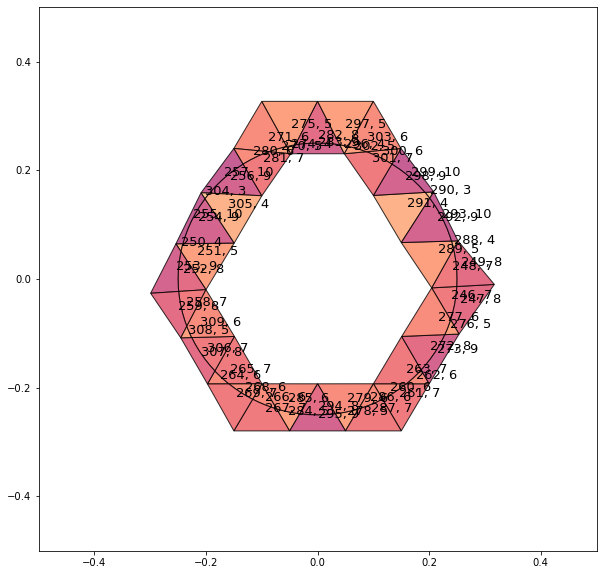

In [486]:
colmap = plt.get_cmap('magma')

# function to visualize
def check_intf_couples (faces, coords, cut_faces, intf_edges, intf_coords):
    fig, ax = plt.subplots(figsize=(10,10))
    ax.set_xlim(-0.5, 0.5)  # x-axis limits from 2 to 8
    ax.set_ylim(-0.5, 0.5)  # y-axis limits from -1 to 1
 
    for couple in gamma_couples:
        for face in couple:
            verts = []
            node_per_face = np.count_nonzero(faces[face,:] != -1)
            
            # draw polygon
            for ino in range(node_per_face):
                point = coords[faces[face,ino],:]
                verts.append(point[0:2])
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=colmap(1-node_per_face/20), alpha=0.8)
            ax.add_patch(element)
            
            # write no of vertices
            bary = barycenter( faces, coords, face)
            text_pos = bary
            text= str(face)+", "+str(node_per_face)
            ax.text(text_pos[0], text_pos[1], text, fontsize=13, color='black')
            

check_intf_couples(faces, coords, cut_faces, intf_edges, intf_coords)

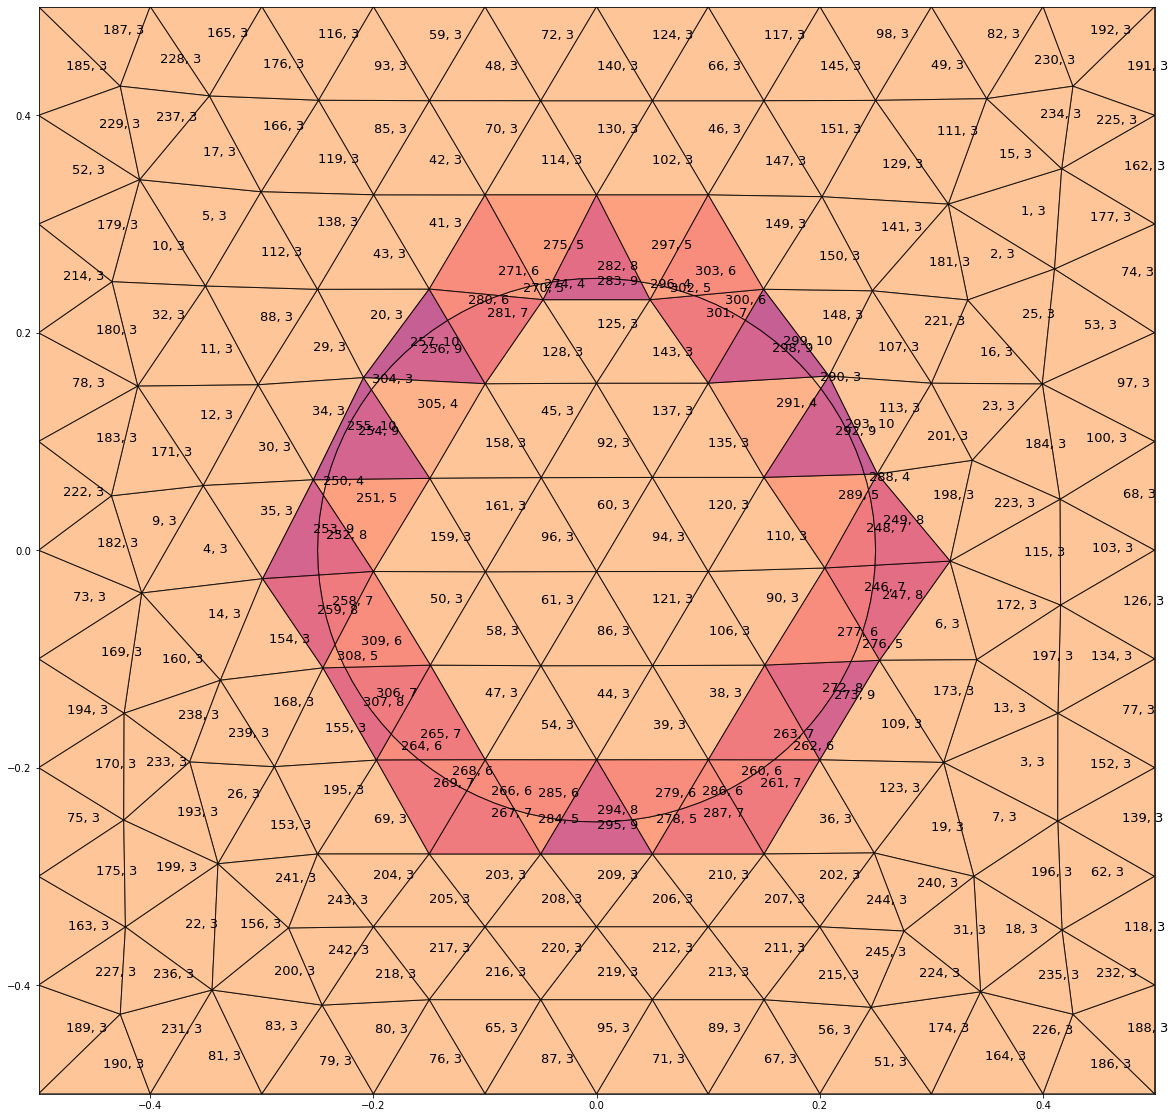

In [473]:
colmap = plt.get_cmap('magma')

# function to visualize
def check(faces, coords, cut_faces, intf_edges, intf_coords):
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_xlim(-0.5, 0.5)  # x-axis limits from 2 to 8
    ax.set_ylim(-0.5, 0.5)  # y-axis limits from -1 to 1
 
    for ifa in range(faces.shape[0]): 
        if (cut_faces[ifa]!=1):
            verts = []
            node_per_face = np.count_nonzero(faces[ifa,:] != -1)
            
            # draw polygon
            for ino in range(node_per_face):
                point = coords[faces[ifa,ino],:]
                verts.append(point[0:2])
            element = Polygon(verts, closed=True, edgecolor='black', facecolor=colmap(1-node_per_face/20), alpha=0.8)
            ax.add_patch(element)
            
            # write no of vertices
            bary = barycenter( faces, coords, ifa)
            text_pos = bary
            text= str(ifa)+", "+str(node_per_face)
            ax.text(text_pos[0], text_pos[1], text, fontsize=13, color='black')
            

check(faces, coords, cut_faces, intf_edges, intf_coords)

### Check if Nodes are repetead

[164 165 166 167 168 169 170 155 117  -1  -1  -1  -1]


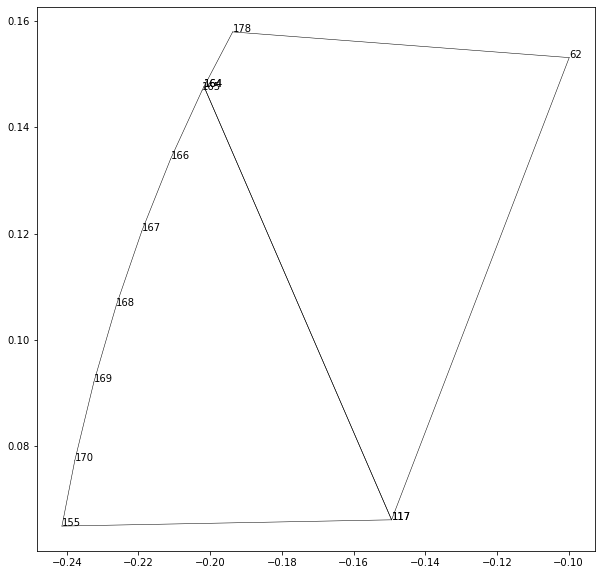

In [464]:
face1 = 254
face2 = 305

def visualize_skeleton(faces, coords):
    fig, ax = plt.subplots(figsize=(10,10))
    for ifa in range(faces.shape[0]):
        if (ifa==face1 or ifa==face2):
            node_per_face =  np.count_nonzero(faces[ifa,:] != -1)
            nvert = node_per_face
            for ino in range(nvert):
                
                # draw edges
                p1 = coords[faces[ifa,ino],:]
                p2 = coords[faces[ifa,(ino+1)%nvert],:]
                dx = p2-p1
                xx = [p1[0],p2[0]]
                yy = [p1[1],p2[1]]
                ax.plot(xx,yy,'k', linewidth=0.5, markersize = 10)
                
                # write no of vertices
                text_pos = p1
                text = str(faces[ifa,ino]) 
                ax.text(text_pos[0], text_pos[1], text, fontsize=10, color='black')
    #ax.scatter(intf_coords[intf_edges[0][0]][0], intf_coords[intf_edges[0][0]][1])
    #ax.scatter(intf_coords[intf_edges[0][1]][0], intf_coords[intf_edges[0][1]][1])

visualize_skeleton(faces, coords)
print (faces[face1,:])

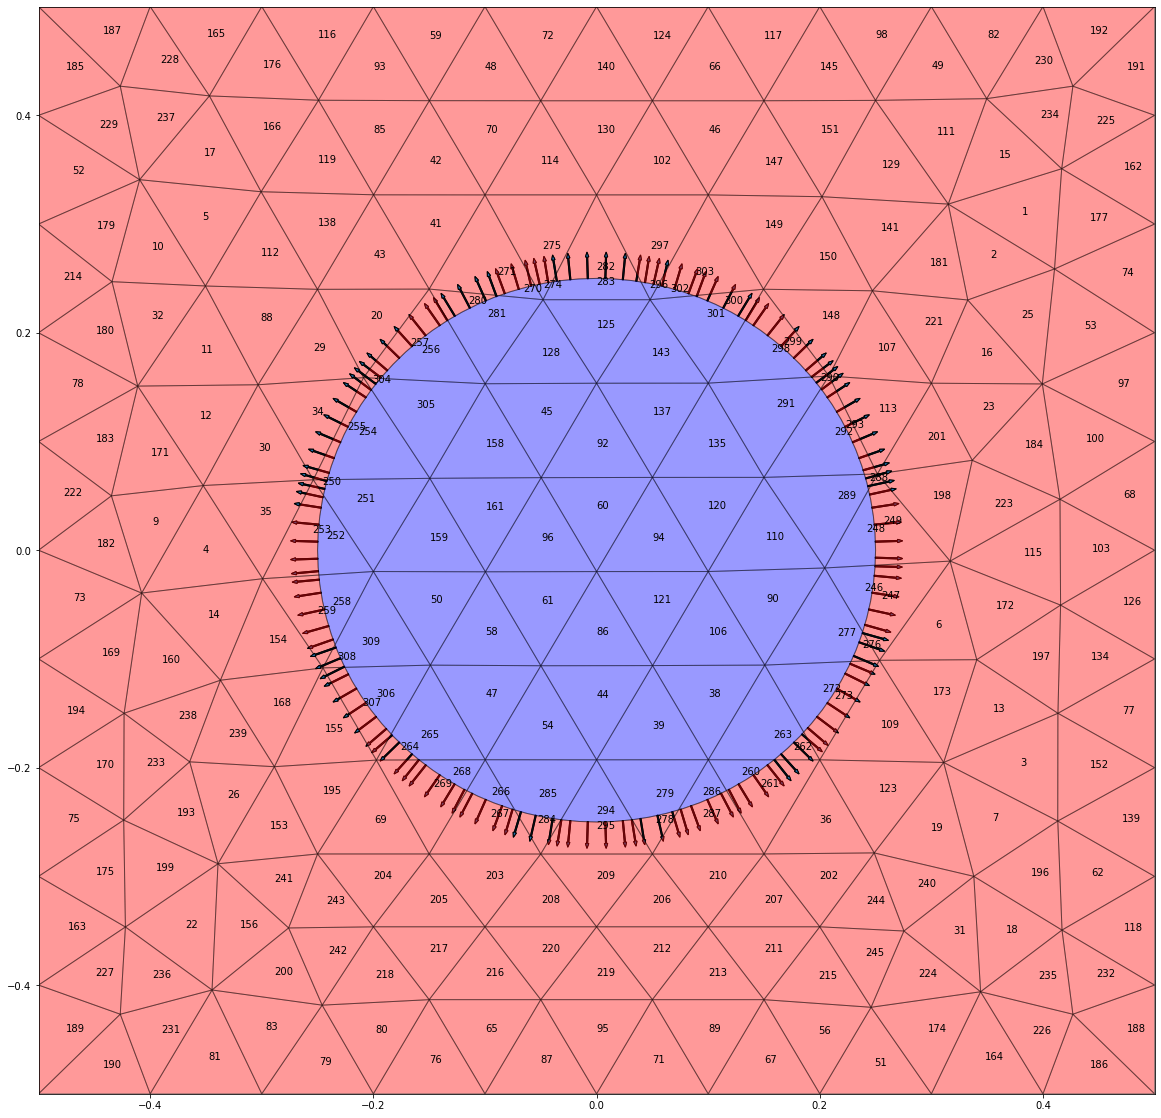

In [467]:
# function to visualize
def check_normals(faces, coords, cut_faces, side_mask, no_intf_faces):
    fig, ax = plt.subplots(figsize=(20,20))
    ax.set_xlim(-0.5, 0.5)  # x-axis limits from 2 to 8
    ax.set_ylim(-0.5, 0.5)  # y-axis limits from -1 to 1
    colors = ['blue', 'red']
 
    for ifa in range(faces.shape[0]): 
        if (cut_faces[ifa]!=1):
            verts = []
            node_per_face = np.count_nonzero(faces[ifa,:] != -1)
            
            # draw polygon and display normal
            for ino in range(node_per_face):
                point = coords[faces[ifa,ino],:]
                verts.append(point[0:2])
                if (ino<no_intf_faces[ifa]):
                    p1 = coords[faces[ifa,ino]]
                    p2 = coords[faces[ifa,ino+1]]
                    start = 0.5*(p1+p2)
                    tang = (p2-p1)[0:2]/np.linalg.norm((p2-p1)[0:2])/50
                    dx = np.dot( np.array([[0, 1], [-1, 0]]), tang)
                    sign = 2*( (1-side_mask[ifa]) -0.5)
                    dx = dx*sign
                    ax.arrow(start[0], start[1], dx[0], dx[1])
                
            element = Polygon(verts, closed=True, edgecolor='black',\
                              facecolor=colors[int(side_mask[ifa])], alpha=0.4)
            ax.add_patch(element)
            
            # write no of element
            text_pos = barycenter(faces, coords, ifa)
            text = str(ifa) 
            ax.text(text_pos[0], text_pos[1], text, fontsize=10, color='black')
            
            

check_normals(faces, coords, cut_faces, side_mask, no_intf_faces)

### Correct Side Mask for Concave Elements

In [466]:
side_mask[255] = 1
side_mask[293] = 1

## Data of The Problem

In [518]:
# other data
sigma_ex = 0.1
sigma_in = 1

#impose_BC(matthieu)
def impose_bc_matthieu(u):
    for ino in range(Npoints_init):
        if (bnd_mask[ino]>0):
            x = coords[ino,0]
            y = coords[ino,1]
            radius = np.sqrt(x**2+y**2)
            u[ino] = x*(1+ (sigma_ex-sigma_in)/(sigma_ex+sigma_in)*(rho/radius)**2)
    return u

# initialize jump datum J_gamma on interface nodes (constant value)
Npoints = coords.shape[0]
Npoints_intface = Npoints-Npoints_init
J_datum = np.zeros((Npoints_intface))
for ino in range(Npoints_intface):
    xx = coords[Npoints_init+ino,0]
    yy = coords[Npoints_init+ino,1]
    J_datum[ino]= 1.0

## Local Discrete Operators

In [383]:
# Discrete Gradient Matrix (dimSpace(=2) ,node_per_face)
def GR (faces, coords, ifa):
    node_per_face = np.count_nonzero(faces[ifa,:] != -1)
    GR = np.zeros((2, node_per_face))
    for ino in range(node_per_face):
        start1 = end2 = np.array(coords[faces[ifa][ino],0:2]) #dx
        start2 = np.array(coords[faces[ifa,(ino-1)%node_per_face], 0:2]) 
        end1   = np.array(coords[faces[ifa,(ino+1)%node_per_face], 0:2])
        tangent1 = (end1-start1)
        tangent2 = (end2-start2)
        # get normal by rotation
        normal1 = np.array([[0,1],[-1,0]])@tangent1
        normal2 = np.array([[0,1],[-1,0]])@tangent2
        norm1 = normal1/np.linalg.norm(normal1)
        norm2 = normal2/np.linalg.norm(normal2)
        mod_F = calc_surface(face, coords, ifa)
        GR[:,ino] = 0.5/mod_F*(normal1+normal2)
    return GR

In [391]:
# Potential RECONSTRUCTION matrix (node_per_face, node_per_face)
def recpot (faces, coords, ifa):
    Nfaces = faces.shape[0]
    node_per_face = np.count_nonzero(faces[ifa,:] != -1)
    dim_basis     = 3 #dimension of basis of R,c2(T) 
    V = np.zeros ((node_per_face, dim_basis)) #evaluation matrix
    M = np.zeros ((dim_basis, dim_basis))     #the mass matrix to invert
    B1 = np.zeros ((dim_basis,node_per_face))  #the rhs matrix (part 1)
    B2 = np.zeros ((dim_basis,node_per_face))  #the rhs matrix (part 2)
    
    x_T = barycenter(faces, coords, ifa) #----->this may cause problems i barycenter doesn't belong to element
    
    #define the psi_i (for edge contribution of B)
    psi = [None for _ in range(dim_basis)]
    psi [0] = lambda x,y:  np.array([x-x_T[0],y-x_T[1]])
    psi [1] = lambda x,y:  np.array([x-x_T[0],y-x_T[1]])*(x-x_T[0])
    psi [2] = lambda x,y:  np.array([x-x_T[0],y-x_T[1]])*(y-x_T[1])
    #define the phi_i (for V)
    phi = [None for _ in range(dim_basis)]
    phi [0] = lambda x,y: 2.
    phi [1] = lambda x,y: 3*(x - x_T[0])
    phi [2] = lambda x,y: 3*(y - x_T[1])
    #define the csi_ij (integrated phi_i*phi_j, for M)
    csi = [[None for _ in range(dim_basis)] for _ in range (dim_basis)]
    csi [0][0] = lambda x,y: np.array([2*(x-x_T[0]), 
                                       2*(y-x_T[1])])
    csi [0][1] = csi[1][0] = lambda x,y: np.array([0., 
                                                   6*(y-x_T[1])*(x-x_T[0])])
    csi [0][2] = csi[2][0] = lambda x,y: np.array([6*(x-x_T[0])*(y-x_T[1]),
                                                   0.])
    csi [1][1] = lambda x,y: np.array([0., 
                                       9*(y-x_T[1])*((x-x_T[0])**2)])
    csi [1][2] = csi[2][1] = lambda x,y: np.array([(9/4)*((x-x_T[0])**2)*(y-x_T[1]), 
                                                   (9/4)*(x-x_T[0])*((y-x_T[1])**2)])
    csi [2][2] = lambda x,y: np.array([9*(x-x_T[0])*((y-x_T[1])**2),
                                       0.])
    #define the chi_iN  (for cell contribution in B)
    chi_fac = [None for _ in range (dim_basis)]
        #visualization
        #if (t == -1):
        #  fig,ax = plt.subplots(figsize=(4,4))
         #   plt.gca().set_aspect('equal', adjustable='box')
          #  start1 = end2 = np.array(nodes[elements[t][j]]) #dx
           # start2 = np.array(nodes[elements[t][(j-1)%node_per_elem]]) #sx
            #end1 = np.array(nodes[elements[t][(j+1)%node_per_elem]])
           # ax.plot([start1[0], end1[0]], [start1[1], end1[1]],'r')
           # ax.plot([start2[0], end2[0]], [start2[1], end2[1]],'r')
            #ax.plot ([start1[0],start1[0]+ e_avg[0] ],
             #        [start1[1],start1[1]+ e_avg[1]])
    chi_fac[0] = lambda  x,y: np.array([(x-x_T[0])*(y-x_T[1]),
                                        (x-x_T[0])*(y-x_T[1])]) 
    chi_fac[1] = lambda  x,y: np.array([0.5*((x-x_T[0])**2)*(y-x_T[1]),
                                        (y-x_T[1])*((x-x_T[0])**2)]) 
    chi_fac[2] = lambda  x,y: np.array([(x-x_T[0])*((y-x_T[1])**2),
                                        0.5*((y-x_T[1])**2)*(x-x_T[0])]) 
    #fill V  
    for i in range(node_per_face):
        xx = coords[faces[ifa][i]][0]
        yy = coords[faces[ifa][i]][1]
        for j in range(dim_basis):
            V[i][j] = phi[j](xx,yy)
    #fill M
    for i in range (dim_basis):
        for j in range (dim_basis):
            #must sum integrals over E of csi*n 
            for k in range(node_per_face):
                # get direction of edge
                start = coords[faces[ifa][k], 0:2]
                end   = coords[faces[ifa][(k+1)%node_per_face], 0:2]
                tangent = (end-start)/np.linalg.norm(end-start)
                # get normal by rotation
                normal = np.array([[0,1],[-1,0]])@tangent
                M [i][j] = M [i][j] + simpson(start, end, lambda x,y: np.dot(normal,csi[i][j] (x,y)))
    #fill B
    for i in range(dim_basis):
        for j in range (node_per_face):
                #face contribution form left and right (need 2 normals)
                start1 = end2 = np.array(coords[faces[ifa][j],0:2]) #dx
                start2 = np.array(coords[faces[ifa][(j-1)%node_per_face], 0:2]) #sx
                end1   = np.array(coords[faces[ifa][(j+1)%node_per_face], 0:2])
                tangent1 = (end1-start1)
                tangent2 = (end2-start2)
                # get normal by rotation
                normal1 = np.array([[0,1],[-1,0]])@tangent1
                normal2 = np.array([[0,1],[-1,0]])@tangent2
                norm1 = normal1/np.linalg.norm(normal1)
                norm2 = normal2/np.linalg.norm(normal2)
                B2 [i][j] = B2 [i][j] + simpson(start1, end1,
                                              lambda x,y: np.dot(norm1,psi[i](x,y)), True, 'minus')#dx
                B2 [i][j] = B2 [i][j] + simpson(start2, end2, 
                                              lambda x,y: np.dot(norm2,psi[i](x,y)), True, 'plus')#sx 
                #cell contribution: must sum integrals over E of chi*n 
                e_avg = 0.5*(normal1 + normal2)
                chi_ij = lambda x,y: np.multiply (np.flip(e_avg), chi_fac[i](x,y))
                for k in range(node_per_face):
                    start = coords[faces[ifa][k],0:2]
                    end = coords[faces[ifa][(k+1)%node_per_face], 0:2]
                    tangent = (end-start)/np.linalg.norm(end-start)
                    # get normal by rotation
                    normal = np.array([[0,1],[-1,0]])@tangent
                    # get surface of face
                    mod_F = calc_surface (faces, coords,ifa)
                    B1[i][j] = B1[i][j] -(1/mod_F)* simpson(start, end, lambda x,y: np.dot(normal,chi_ij(x,y)))
    #calculate the final local matrix S an store it
    R = np.dot(V, np.linalg.solve(M,(B1+B2)))
    
    return R

### Test Reconstruction 

In [468]:
# test reconstruction: initialize poli1 function and check gradient and recpot 
# recpot should be exact for pol1

Npoints = coords.shape[0]
Nfaces = faces.shape[0]

u = np.zeros(Npoints)
for ino in range(Npoints):
    x = coords[ino,0]
    y = coords[ino,0]
    u[ino] = x + y

for ifa in range(Nfaces):
    if (cut_faces[ifa]!=1):
        print ("Face no:", ifa)
        node_per_face = np.count_nonzero(faces[ifa,:] != -1)
        u_F = u[faces[ifa,0:node_per_face]]
        grad = GR(faces, coords, ifa)
        print("Nodal values", u_F)
        print ("Gradient: ", np.dot(grad,u_F))
        R = recpot(faces, coords, ifa)
        print("Reconstruction", np.dot(R,u_F))
        print ("*************")
        if (np.linalg.norm( u_F- np.dot(R,u_F) )>1e-6):
            
            print ("Error")

Face no: 1
Nodal values [0.82074078 0.83352647 0.63024155]
Gradient:  [2. 0.]
Reconstruction [0.82074078 0.83352647 0.63024155]
*************
Face no: 2
Nodal values [0.63024155 0.66519238 0.82074078]
Gradient:  [2. 0.]
Reconstruction [0.63024155 0.66519238 0.82074078]
*************
Face no: 3
Nodal values [0.62196288 0.82649409 0.82679492]
Gradient:  [2. 0.]
Reconstruction [0.62196288 0.82649409 0.82679492]
*************
Face no: 4
Nodal values [-0.81526415 -0.59842297 -0.70499209]
Gradient:  [2.0000000e+00 8.8817842e-16]
Reconstruction [-0.81526415 -0.59842297 -0.70499209]
*************
Face no: 5
Nodal values [-0.81886055 -0.70101521 -0.60118215]
Gradient:  [2. 0.]
Reconstruction [-0.81886055 -0.70101521 -0.60118215]
*************
Face no: 6
Nodal values [0.50707913 0.68138725 0.63359727]
Gradient:  [2. 0.]
Reconstruction [0.50707913 0.68138725 0.63359727]
*************
Face no: 7
Nodal values [0.62196288 0.67610624 0.82649409]
Gradient:  [2. 0.]
Reconstruction [0.62196288 0.6761062

Reconstruction [2.75215629e-12 1.00001262e-01 2.00000000e-01]
*************
Face no: 125
Nodal values [-9.59156031e-02  1.92785637e-06  9.59266854e-02]
Gradient:  [ 2.0000000e+00 -6.7332343e-17]
Reconstruction [-9.59156031e-02  1.92785637e-06  9.59266854e-02]
*************
Face no: 126
Nodal values [1.         0.83154819 1.        ]
Gradient:  [2. 0.]
Reconstruction [1.         0.83154819 1.        ]
*************
Face no: 128
Nodal values [-9.59156031e-02 -1.99688655e-01  1.92785637e-06]
Gradient:  [2. 0.]
Reconstruction [-9.59156031e-02 -1.99688655e-01  1.92785637e-06]
*************
Face no: 129
Nodal values [0.49985875 0.40392492 0.63024155]
Gradient:  [2. 0.]
Reconstruction [0.49985875 0.40392492 0.63024155]
*************
Face no: 130
Nodal values [ 7.56768029e-06  1.00001262e-01 -9.99999997e-02]
Gradient:  [2. 0.]
Reconstruction [ 7.56768029e-06  1.00001262e-01 -9.99999997e-02]
*************
Face no: 134
Nodal values [1.         0.83154819 0.82679492]
Gradient:  [2. 0.]
Reconstruc

Reconstruction [-1.         -0.85358984 -0.8       ]
*************
Face no: 188
Nodal values [1.         0.85358984 1.        ]
Gradient:  [2. 0.]
Reconstruction [1.         0.85358984 1.        ]
*************
Face no: 189
Nodal values [-1.         -0.85358984 -1.        ]
Gradient:  [2. 0.]
Reconstruction [-1.         -0.85358984 -1.        ]
*************
Face no: 190
Nodal values [-0.8        -0.85358984 -1.        ]
Gradient:  [2. 0.]
Reconstruction [-0.8        -0.85358984 -1.        ]
*************
Face no: 191
Nodal values [1.         0.85358984 1.        ]
Gradient:  [2. 0.]
Reconstruction [1.         0.85358984 1.        ]
*************
Face no: 192
Nodal values [0.8        0.85358984 1.        ]
Gradient:  [2. 0.]
Reconstruction [0.8        0.85358984 1.        ]
*************
Face no: 193
Nodal values [-0.67845057 -0.72920006 -0.84740337]
Gradient:  [2. 0.]
Reconstruction [-0.67845057 -0.72920006 -0.84740337]
*************
Face no: 194
Nodal values [-1.         -0.84671626 

Reconstruction [-0.38743769 -0.38525662 -0.36448431 -0.34227355 -0.31871199 -0.29389263
 -0.2679134  -0.26683352 -0.3        -0.41764211]
*************
Face no: 258
Nodal values [-0.49765821 -0.49605735 -0.49114363 -0.48429158 -0.47552826 -0.46859658
 -0.4       ]
Gradient:  [2.0000000e+00 4.4408921e-16]
Reconstruction [-0.49765821 -0.49605735 -0.49114363 -0.48429158 -0.47552826 -0.46859658
 -0.4       ]
*************
Face no: 259
Nodal values [-0.46859658 -0.47552826 -0.48429158 -0.49114363 -0.49605735 -0.49765821
 -0.59842297 -0.49037914]
Gradient:  [2. 0.]
Reconstruction [-0.46859658 -0.47552826 -0.48429158 -0.49114363 -0.49605735 -0.49765821
 -0.59842297 -0.49037914]
*************
Face no: 260
Nodal values [0.23290976 0.24087684 0.2679134  0.29389263 0.31831349 0.20026268]
Gradient:  [2.00000000e+00 1.77635684e-15]
Reconstruction [0.23290976 0.24087684 0.2679134  0.29389263 0.31831349 0.20026268]
*************
Face no: 261
Nodal values [0.31831349 0.29389263 0.2679134  0.24087684 0

Reconstruction [-6.36313338e-02 -6.26666168e-02 -3.13952598e-02 -7.45931095e-17
  3.13952598e-02  6.26666168e-02  6.36892143e-02  8.69102457e-05]
*************
Face no: 295
Nodal values [ 6.36892143e-02  6.26666168e-02  3.13952598e-02 -9.18485099e-17
 -3.13952598e-02 -6.26666168e-02 -6.36313338e-02 -9.99999938e-02
  1.00000005e-01]
Gradient:  [2.00000000e+00 2.22044605e-16]
Reconstruction [ 6.36892143e-02  6.26666168e-02  3.13952598e-02 -7.63278329e-17
 -3.13952598e-02 -6.26666168e-02 -6.36313338e-02 -9.99999938e-02
  1.00000005e-01]
*************
Face no: 296
Nodal values [0.11030016 0.09369066 0.07973275 0.09592669]
Gradient:  [2. 0.]
Reconstruction [0.11030016 0.09369066 0.07973275 0.09592669]
*************
Face no: 297
Nodal values [7.97327463e-02 9.36906573e-02 1.10300165e-01 2.00001926e-01
 7.56768029e-06]
Gradient:  [2. 0.]
Reconstruction [7.97327463e-02 9.36906573e-02 1.10300165e-01 2.00001926e-01
 7.56768029e-06]
*************
Face no: 298
Nodal values [0.38538588 0.38525662 0

## Utilities for the Scheme: local2global index map

In [477]:
# Convention: internal unknowns, intface unknowns side in, intface unknowns side ex
def glob_idx (faces, coords, Npoints_init, ifa, ino):
    idx_point = faces[ifa,ino]
    if (idx_point<Npoints_init):
    # point is from the original mesh: not on the int.face
        return idx_point
    else:
    # interface point, doubled: unknown structure: 
    # [internal unknowns, internal intface unk, external intface unknowns]
        side = side_mask[ifa]
        if (side==0):
            return Npoints_init + (idx_point-Npoints_init)
        elif (side==1):
            #return Npoints_init +(Npoints-Npoints_init)+(idx_point-Npoints_init)
            return idx_point + (Npoints-Npoints_init)
        else:
            print ("Error: this face is cut")

# Kronecker Delta
def kron(i,j):
    if (i==j):
        return 1
    else:
        return 0
    
# Define number of dofs
Npoints = coords.shape[0]
Ndof = Npoints_init + 2*(Npoints-Npoints_init)

### G and S matrices

In [500]:
# Assemble matrix G (grad-grad)
G = np.zeros((Ndof,Ndof))
for ifa in range(Nfaces):
    side = side_mask[ifa]
    if (cut_faces[ifa] != 1):
        node_per_face = np.count_nonzero(faces[ifa,:] != -1)
        GRAD = GR(faces, coords, ifa)
        mod_F = calc_surface(faces, coords, ifa)
        sigma = (1-side)*sigma_in + side*sigma_ex
        for i in range(node_per_face):
            for j in range(node_per_face):
                glob_i = glob_idx(faces, coords, Npoints_init, ifa,i)
                glob_j = glob_idx(faces, coords, Npoints_init, ifa,j)
                G[glob_i,glob_j] = G[glob_i,glob_j] +sigma*mod_F*np.dot(GRAD[:,i],GRAD[:,j])

# Assemble matrix S (stabilization)
S = np.zeros((Ndof,Ndof))
for ifa in range(Nfaces):
    if (cut_faces[ifa] != 1):
        node_per_face = np.count_nonzero(faces[ifa,:] != -1)
        R = recpot(faces, coords, ifa)
        for i in range(node_per_face):
            for j in range(node_per_face):
                glob_i = glob_idx(faces, coords, Npoints, ifa,i)
                glob_j = glob_idx(faces, coords, Npoints, ifa,j)
                for k in range (node_per_face):
                    S[glob_i,glob_j] = S[glob_i,glob_j] + (R[k,i]-kron(i,k))*(R[k,j]-kron(j,k))

### M_Gamma (direct jump, not jump of reconstruction)

In [509]:
def assemble_M_gamma(coords, faces, no_intf_edges, Ndof, Npoints_init, sigma_in,sigma_ex):
    # Matrix M_gamma (jump of gradient)
    M_gamma = np.zeros((Ndof,Ndof))
    
    for ico in range(len(gamma_couples)):
        
# prepare list of dofs
###############################################################################################################        
        # table of dofs touched by the edge
        
        ifa_in = gamma_couples[ico][0] # in place of gamma_edges the list of intface face couples  
        ifa_ex = gamma_couples[ico][1]
        
        no_intf_nodes  = no_intf_faces[ifa_in] + 1 
        
        tot_dofs = 2*no_intf_nodes + 3 # intf nodes counted 2 times + original vertices
        edge_dofs = np.zeros((tot_dofs, 2), dtype=int)
        
        node_per_face_in = np.count_nonzero(faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(faces[ifa_ex,:] != -1)
        
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = glob_idx(faces, coords, Npoints_init, ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = glob_idx(faces, coords, Npoints_init, ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
            
# assemble matrix            
################################################################################################################
            
        # loop over i 
        for idof1 in range(tot_dofs):
            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1] #idx of face
            GR1 = GR(faces, coords, ifa1)
            sigma1 = sigma_in*int(ifa1==ifa_in) + sigma_ex*int(ifa1==ifa_ex)
            sign1 = int(ifa1==ifa_in)-int(ifa1==ifa_ex)

            
            # loop over j 
            for idof2 in range(tot_dofs):
                dof2 = edge_dofs[idof1,0] #global idx
                if (idof2<node_per_face_in): #local idx
                    dof2_loc = idof2
                else:
                    dof2_loc = idof2-node_per_face_in
                ifa2 = edge_dofs[idof2,1] #idx of face
                
                # mask of affected interface edges
                in_support_of_j = np.zeros((no_intf_edges[ifa_in]), dtype=int)
                if (j<no_intf_edges[ifa_in]):
                    in_support_of_j[j] = 1
                if (j>0 and (j-1)<no_intf_edges[ifa_in]):
                    in_support_of_j[j-1] = 1
                
                # loop over interface edges of the couple 
                for ied in range(no_intf_edges[ifa_in]):
                    
                    # non null contribution if edge in support of phi_j
                    if (in_support_of_j[ied]==1):
                        # find normal
                        tangent = coords[faces[ifa1,(ied+1)],0:2] \
                                 -coords[faces[ifa1, ied   ],0:2] # should be safe not to take %
                        normal  = sign1*np.array([[0,1],[-1,0]])@tangent
                        # G(phi_i) times normal
                        mean_sigma_grad_normal = 0.5*sigma1*np.dot(GR1[:,dof1_loc], normal)
                    
                        # add contribution
                        M_gamma[dof1,dof2] = M_gamma[dof1,dof2] + mean_sigma_grad_normal*0.5
            
    return M_gamma         

M_gamma = assemble_M_gamma(coords, faces, no_intf_edges, Ndof, Npoints_init, sigma_in ,sigma_ex)

### N_Gamma matrix and b_J vector (ex b_phi)

In [511]:
# calculate the integral over the [0,1] of the product between 2 affine functions assigned through their 
# values at vertices 0 and 1 (first values at 0 of f1 and f2 an then values at 1)
def calc_r2_prod_integ(v1A,v1B,v2A,v2B): 
    return v1A*v2A*1/3 + (v1A*v2B+v1B*v2A)*1/6 + v1B*v2B*1/3




def assemble_N_gamma(coords, faces, no_intf_edges, Ndof, Npoints_init, sigma_in,sigma_ex):
    
    N_gamma = np.zeros((Ndof,Ndof))
    
    for ico in range(len(gamma_couples)):
        
# prepare list of dofs
###############################################################################################################        
        # table of dofs touched by the edge
        
        ifa_in = gamma_couples[ico][0] # in place of gamma_edges the list of intface face couples  
        ifa_ex = gamma_couples[ico][1]
        
        no_intf_nodes  = no_intf_faces[ifa_in] + 1 
        
        tot_dofs = 2*no_intf_nodes + 3 # intf nodes counted 2 times + original vertices
        edge_dofs = np.zeros((tot_dofs, 2), dtype=int)
        
        node_per_face_in = np.count_nonzero(faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(faces[ifa_ex,:] != -1)
        
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = glob_idx(faces, coords, Npoints_init, ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = glob_idx(faces, coords, Npoints_init, ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
            
# assemble matrix            
################################################################################################################
            
        # loop over i 
        for idof1 in range(tot_dofs):
            dof1 = edge_dofs[idof1,0] #global idx
            if (idof1<node_per_face_in): #local idx
                dof1_loc = idof1
            else:
                dof1_loc = idof1-node_per_face_in
            ifa1 = edge_dofs[idof1,1] #idx of face
            GR1 = GR(faces, coords, ifa1)
            sigma1 = sigma_in*int(ifa1==ifa_in) + sigma_ex*int(ifa1==ifa_ex)
            sign1 = int(ifa1==ifa_in)-int(ifa1==ifa_ex)
            
            # mask of affected interface edges
            in_support_of_i = np.zeros((no_intf_edges[ifa_in]), dtype=int)
            if (i<no_intf_edges[ifa_in]):
                in_support_of_i[i] = 1
            if (i>0 and (i-1)<no_intf_edges[ifa_in]):
                in_support_of_i[i-1] = 1

            
            # loop over j 
            for idof2 in range(tot_dofs):
                dof2 = edge_dofs[idof1,0] #global idx
                if (idof2<node_per_face_in): #local idx
                    dof2_loc = idof2
                else:
                    dof2_loc = idof2-node_per_face_in
                ifa2 = edge_dofs[idof2,1] #idx of face
                
                # mask of affected interface edges
                in_support_of_j = np.zeros((no_intf_edges[ifa_in]), dtype=int)
                if (j<no_intf_edges[ifa_in]):
                    in_support_of_j[j] = 1
                if (j>0 and (j-1)<no_intf_edges[ifa_in]):
                    in_support_of_j[j-1] = 1
                
                # loop over interface edges of the couple
                for ied in range(no_intf_edges[ifa_in]):
                    v1A = kron(ied, dof1_loc)
                    v1B = kron(ied, dof1_loc+1)
                    v2A = kron(ied, dof2_loc)
                    v2B = kron(ied, dof2_loc+1)
                    
                    sign1 = int(ifa1==ifa_ex)-int(ifa1==ifa_in)
                    sign2 = int(ifa2==ifa_ex)-int(ifa2==ifa_in)
                    
                    tangent = coords[faces[ifa1,(ied+1)],0:2] -coords[faces[ifa1, ied   ],0:2]
                    mod_E = np.linalg.norm(tangent)
                    
                    # add contribution
                    N_gamma[dof1,dof2] = N_gamma[dof1,dof2] \
                              +  sign1*sign2*mod_E*calc_r2_prod_integ(v1A,v1B,v2A,v2B) 
            
    return N_gamma         

N_gamma = assemble_N_gamma(coords, faces, no_intf_edges, Ndof, Npoints_init, sigma_in ,sigma_ex)

In [516]:


def assemble_B_J_gamma(coords, faces, no_intf_edges, Ndof, Npoints_init, sigma_in,sigma_ex):
    
    B_J_gamma = np.zeros(Ndof)
    
    for ico in range(len(gamma_couples)):
        
# prepare list of dofs
###############################################################################################################        
        # table of dofs touched by the edge
        
        ifa_in = gamma_couples[ico][0] # in place of gamma_edges the list of intface face couples  
        ifa_ex = gamma_couples[ico][1]
        
        no_intf_nodes  = no_intf_faces[ifa_in] + 1 
        
        tot_dofs = 2*no_intf_nodes + 3 # intf nodes counted 2 times + original vertices
        edge_dofs = np.zeros((tot_dofs, 2), dtype=int)
        
        node_per_face_in = np.count_nonzero(faces[ifa_in,:] != -1)
        node_per_face_ex = np.count_nonzero(faces[ifa_ex,:] != -1)
        
        # dofs ifa_in
        for ino_in in range(node_per_face_in):
            edge_dofs[ino_in,0] = glob_idx(faces, coords, Npoints_init, ifa_in, ino_in)
            edge_dofs[ino_in,1] = ifa_in
        # dofs ifa_ex
        for ino_ex in range(node_per_face_ex):
            edge_dofs[node_per_face_in+ino_ex,0] = glob_idx(faces, coords, Npoints_init, ifa_ex, ino_ex)
            edge_dofs[node_per_face_in+ino_ex,1] = ifa_ex
            
# assemble matrix            
################################################################################################################
            
        # loop over i 
        for idof in range(tot_dofs):
            dof = edge_dofs[idof,0] #global idx
            if (idof<node_per_face_in): #local idx
                dof_loc = idof
            else:
                dof_loc = idof-node_per_face_in
            ifa = edge_dofs[idof,1] #idx of face
            
            sign = int(ifa==ifa_in)-int(ifa==ifa_ex)
        
            # loop over interface edges of the couple
            for ied in range(no_intf_edges[ifa_in]):
                
                v1A = kron(ied, dof_loc)
                v1B = kron(ied, dof_loc+1)
                
                ino1 = faces[ifa,ied]
                ino2 = faces[ifa,ied+1]
                
                v2A = J_datum[ino1-Npoints_init]
                v2B = J_datum[ino2-Npoints_init]
                    
                tangent = coords[faces[ifa,(ied+1)],0:2] -coords[faces[ifa, ied],0:2]
                mod_E = np.linalg.norm(tangent)
                    
                # add contribution
                B_J_gamma[dof] = B_J_gamma[dof] \
                                     + sign*mod_E*calc_r2_prod_integ(v1A,v1B,v2A,v2B) 
            
    return B_J_gamma         

B_J_gamma = assemble_B_J_gamma(coords, faces, no_intf_edges, Ndof, Npoints_init, sigma_in ,sigma_ex)

## Solution with GMRES Solver

In [532]:
def impose_bc_matthieu(faces, coords, Npoints_init, Ndof, A, b):
    Npoints = coords.shape[0]
        
    for ino in range(Npoints_init):
        if (bnd_mask[ino]>0):
            
            x = coords[ino,0]
            y = coords[ino,1]
            radius = np.sqrt(x**2+y**2)
            b[ino] = x*(1+(sigma_ex-sigma_in)/(sigma_ex+sigma_in)*(rho/radius)**2)
            
            A[ino,:] = 0.0
            A[ino,ino] = 1
            
    return [A,b]

In [533]:
# SOLVE SYSTEM BY DIRECT METHOD: homogenous dirichlet and constant jump 

# stability parameter:
eta = 1e3

# gmrs tolerance
tolerance = 1e-20

# Matrix and rhs before bc conds
A = G+S+eta*N_gamma+np.transpose(M_gamma) 
b = eta*B_J_gamma

# impose BCs
[A, b] = impose_bc_matthieu(faces, coords, Npoints_init, Ndof, A, b)
    
# solve using gmres at fixed tolerace
u, info = gmres(A, b, tol=tolerance)

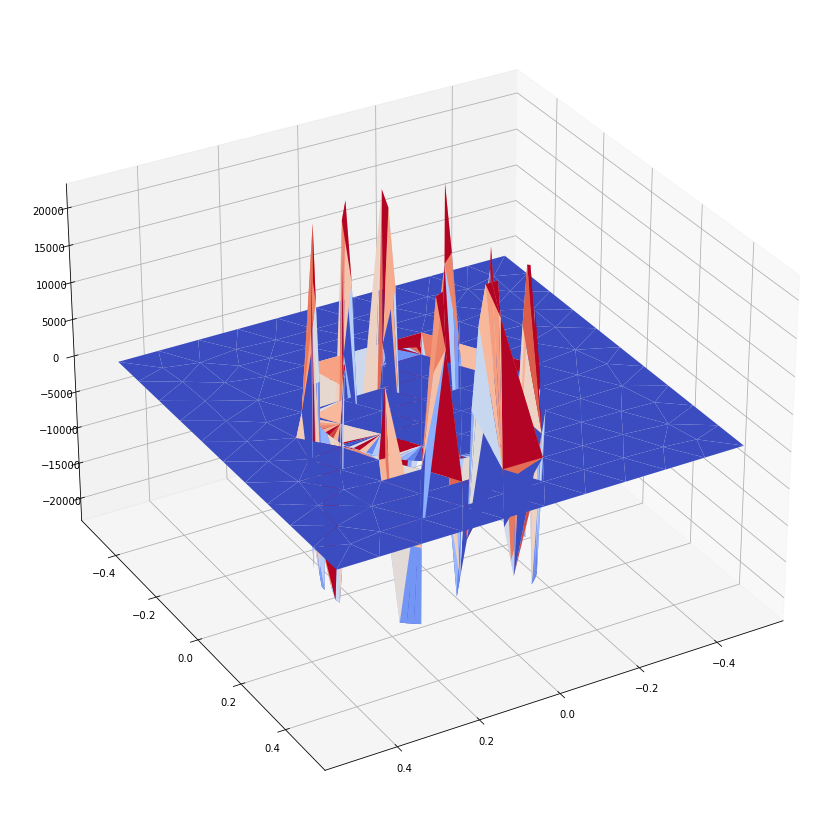

In [539]:
# Visualization 

elevation = 30
azimuth = 60

fig = plt.figure(figsize = (15,15))
ax  = fig.add_subplot(111, projection='3d')
ax.view_init(elev=elevation, azim=azimuth)
    
for ifa in range(Nfaces):
    if (cut_faces[ifa]!=1):
        node_per_face = np.count_nonzero(faces[ifa,:] != -1)
        u_F = np.zeros(node_per_face)
        xx  = np.zeros(node_per_face)
        yy  = np.zeros(node_per_face)
        for ino in range(node_per_face):
            xx[ino], yy[ino] = coords[faces[ifa][ino],0:2]
            ino_glob = glob_idx(faces, coords, Npoints_init, ifa,ino)
            u_F [ino] = u [ino_glob]
        surf = ax.plot_trisurf(xx, yy, u_F, cmap=cm.coolwarm)
plt.show()

In [531]:
Npoints_init-1

143